In [9]:
import os, json, joblib
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import reciprocal, uniform
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt




In [11]:

df = pd.read_csv("TrainDataset2025.csv")
df = df.replace(999, np.nan)


In [12]:
# 2) Setup target & ID
TARGET = "RelapseFreeSurvival (outcome)"
ID_COL = "ID"
df = df.drop(columns=["pCR (outcome)"])  # drop PCR since we only do RFS here
ID_series = df[ID_COL].astype(str)
y = df[TARGET]
X = df.drop(columns=[TARGET])



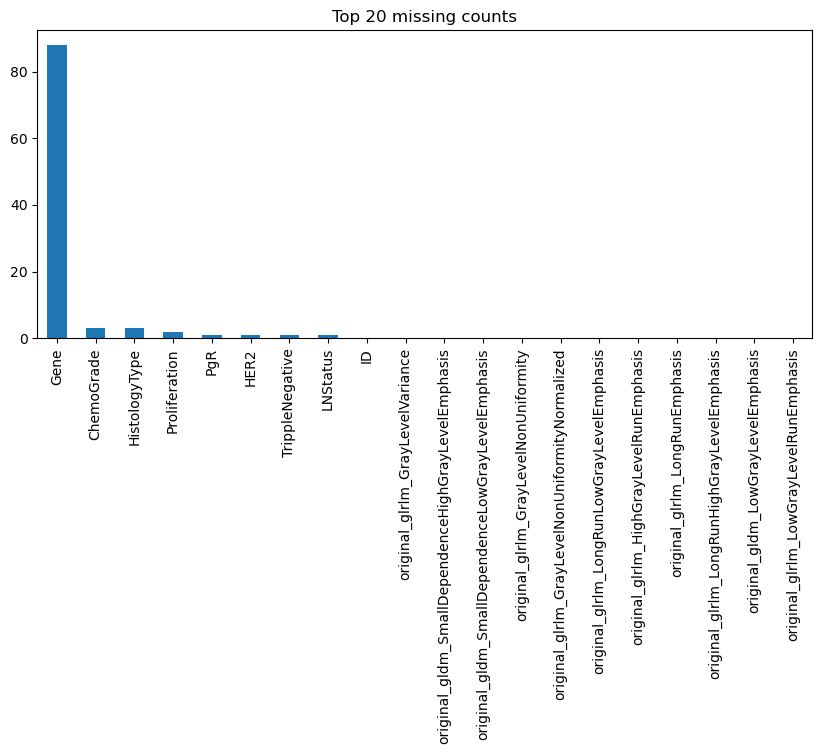

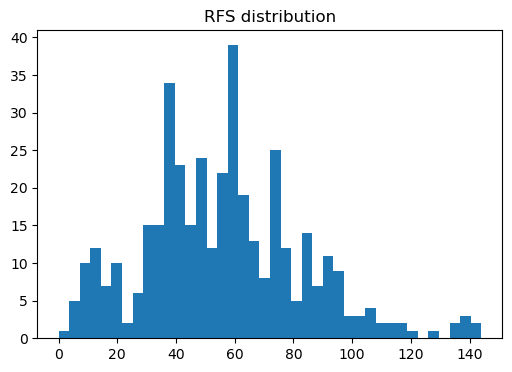

In [14]:
#VISUALIZATION
# missing counts
mv = X.isna().sum().sort_values(ascending=False)
plt.figure(figsize=(10,4)); mv.head(20).plot.bar(); plt.title("Top 20 missing counts"); plt.xticks(rotation=90); plt.show()
# target histogram
plt.figure(figsize=(6,4)); plt.hist(y.dropna(), bins=40); plt.title("RFS distribution"); plt.show()

In [15]:
# Separate numeric and categorical (exclude ID)
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
if ID_COL in cat_cols:
    cat_cols.remove(ID_COL)



In [16]:
# Train/val split
X_train_raw, X_val_raw, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=42)



In [17]:
# Fit imputers on TRAIN only
num_imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=50, random_state=42),
    max_iter=10, random_state=42, initial_strategy='median'
)
X_train_num = pd.DataFrame(num_imputer.fit_transform(X_train_raw[num_cols]), columns=num_cols, index=X_train_raw.index)
X_val_num   = pd.DataFrame(num_imputer.transform(X_val_raw[num_cols]), columns=num_cols, index=X_val_raw.index)

if len(cat_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_train_cat = pd.DataFrame(cat_imputer.fit_transform(X_train_raw[cat_cols]), columns=cat_cols, index=X_train_raw.index)
    X_val_cat   = pd.DataFrame(cat_imputer.transform(X_val_raw[cat_cols]), columns=cat_cols, index=X_val_raw.index)
else:
    cat_imputer=None
    X_train_cat = pd.DataFrame(index=X_train_raw.index)
    X_val_cat   = pd.DataFrame(index=X_val_raw.index)



In [18]:
#  Combine numeric + categorical after imputation
X_train_prep = pd.concat([X_train_num, X_train_cat], axis=1)
X_val_prep   = pd.concat([X_val_num, X_val_cat], axis=1)



In [19]:
# Feature selection
must_keep = ["ER", "HER2", "Gene"]
corr_matrix = X_train_prep.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.90) and col not in must_keep]

X_train_fs = X_train_prep.drop(columns=to_drop)
X_val_fs   = X_val_prep.drop(columns=[c for c in to_drop if c in X_val_prep.columns])



In [20]:
# Rank using RandomForest
rf_rank = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_rank.fit(X_train_fs, y_train)
importances = rf_rank.feature_importances_
ranked_idx = np.argsort(importances)[::-1]
ranked_features = X_train_fs.columns[ranked_idx]

N = 40
selected = list(ranked_features[:N])
for f in must_keep:
    if f in X_train_fs.columns and f not in selected:
        selected.append(f)

#  Reduce sets
X_train_sel = X_train_fs[selected]
X_val_sel   = X_val_fs[selected]



In [22]:
#  SVR RandomizedSearch
pipe = Pipeline([("power", PowerTransformer(method="yeo-johnson", standardize=True)),
                 ("svr", SVR())])

param_dist = {
    'svr__kernel': ['rbf'],
    'svr__C': reciprocal(1, 1000),
    'svr__gamma': ['scale','auto', 1e-3, 1e-4],
    'svr__epsilon': uniform(0.01, 2.0)
}

rs = RandomizedSearchCV(pipe, param_distributions=param_dist, n_iter=60, cv=5,
                        scoring='neg_mean_absolute_error', random_state=42, n_jobs=-1, verbose=1)
rs.fit(X_train_sel, y_train)

best_model = rs.best_estimator_



Fitting 5 folds for each of 60 candidates, totalling 300 fits


In [23]:
#  Evaluate
y_val_pred = best_model.predict(X_val_sel)
print("Val MAE:", mean_absolute_error(y_val, y_val_pred),
      "RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))



Val MAE: 22.173756156891482 RMSE: 28.760367588536294


In [24]:
# Refit full dataset
X_num_full = pd.DataFrame(num_imputer.transform(X[num_cols]), columns=num_cols, index=X.index)
if cat_imputer is not None:
    X_cat_full = pd.DataFrame(cat_imputer.transform(X[cat_cols]), columns=cat_cols, index=X.index)
else:
    X_cat_full = pd.DataFrame(index=X.index)
X_full_prep = pd.concat([X_num_full, X_cat_full], axis=1)
X_full_prep = X_full_prep.drop(columns=to_drop, errors='ignore')
X_full_sel = X_full_prep[selected]

best_model.fit(X_full_sel, y)



,steps,"[('power', ...), ('svr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,method,'yeo-johnson'
,standardize,True
,copy,True
,kernel,'rbf'
,degree,3
,gamma,'auto'
,coef0,0.0


In [25]:
# Save artifacts
OUT_DIR = "."
os.makedirs(OUT_DIR, exist_ok=True)
joblib.dump(num_imputer, os.path.join(OUT_DIR,'num_imputer.joblib'))
if cat_imputer is not None:
    joblib.dump(cat_imputer, os.path.join(OUT_DIR,'cat_imputer.joblib'))
joblib.dump(selected, os.path.join(OUT_DIR,'selected_features.pkl'))
joblib.dump(best_model, os.path.join(OUT_DIR,'svr_final_trained_on_all.joblib'))
with open(os.path.join(OUT_DIR,'to_drop.json'),'w') as f:
    json.dump(to_drop, f)
with open(os.path.join(OUT_DIR,'meta.json'),'w') as f:
    json.dump({"target_col":TARGET, "id_col":ID_COL, "num_cols":num_cols, "cat_cols":cat_cols}, f)

print("Saved artifacts to", OUT_DIR)




Saved artifacts to .
